In [1]:
# Parameters
BATCH_MODE = "true"


# 23. Mécanique d'inférence LLM : le KV-cache, from scratch puis mesuré sur notre vLLM

**Navigation** : [Index](README.md) | [<< Précédent](22_Evaluating_Generated_Text.ipynb) | [10_LocalLlama](10_LocalLlama.ipynb) · [11_Quantization](11_Quantization.ipynb)

## Objectifs

Les notebooks [10_LocalLlama](10_LocalLlama.ipynb) et [11_Quantization](11_Quantization.ipynb) couvrent le **déploiement** de notre stack self-hosted (vLLM, quantification). Ce notebook ouvre la cage : la **mécanique interne** de l'inférence autorégressive.

1. **Le mur du recalcul** : pourquoi une génération naïve ralentit avec la longueur du contexte — mesuré, pas affirmé.
2. **Le KV-cache implémenté à la main** : incrémentalité, exactitude numérique vérifiée contre le passage naïf (écart affiché).
3. **Le speedup mesuré** : tokens/s naïf vs caché, à longueur de contexte croissante — la courbe de l'accélération.
4. **Le coût mémoire du cache** : la formule (couches × têtes × head_dim × seq × 2 × dtype) confrontée au mesuré.
5. **Le pont vers la production** : time-to-first-token et inter-token latency **mesurés sur notre vLLM** (qwen3.6-35b-a3b self-hosted), reliés aux mécaniques de la partie 1.

**Prérequis** : PyTorch (CPU suffit pour la partie from scratch), notebook 10 (concepts de déploiement). La partie 5 interroge le vLLM du dépôt (service GPU distant) — si le service est éteint, le notebook affiche un verdict `[RECOVERABLE-MACHINE]` explicite et **aucune valeur de substitution**.

**Durée estimée** : 60 minutes


In [2]:
# Parameters
BATCH_MODE = "true"


## Setup

Un mini-GPT **écrit ici, en PyTorch pur** (CPU), sert de moteur d'étude. Poids aléatoires à seed fixe : ce notebook enseigne la **mécanique** (le coût et la forme des calculs), pas la qualité du texte — un modèle non entraîné produit du bruit, mais son attention coûte exactement ce que coûte celle d'un vrai modèle.


In [3]:
import os
import time
import math
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from dotenv import load_dotenv

%matplotlib inline

torch.manual_seed(20260825)
DEVICE = torch.device("cpu")
print("torch", torch.__version__, "| device:", DEVICE)


torch 2.8.0+cu126 | device: cpu


## 1. Le problème : la génération naïve recalcule tout le préfixe

Une boucle de génération autorégressive produit le token t+1 à partir des logits de la position t. L'implémentation naïve la plus simple ré-exécute le modèle sur **toute la séquence** à chaque pas :

- pas 1 : forward sur `n` tokens (le prompt)
- pas 2 : forward sur `n+1` tokens
- ...
- pas k : forward sur `n+k-1` tokens

Or, dans l'attention, les projections **K** (clés) et **V** (valeurs) des tokens **passés ne changent jamais** : un token déjà encodé produit les mêmes K/V à chaque passage. Le recalcul est du travail **purement perdu**, et il croît avec le carré de la longueur générée.

Construisons d'abord le moteur, puis mesurons ce mur.


In [4]:
class MiniGPTConfig:
    def __init__(self, vocab_size=1000, block_size=1536, n_layer=4, n_head=4, d_model=128):
        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layer = n_layer
        self.n_head = n_head
        self.d_model = d_model

CFG = MiniGPTConfig()
assert CFG.d_model % CFG.n_head == 0  # invariant de découpage des têtes
CFG.head_dim = CFG.d_model // CFG.n_head


class CausalSelfAttention(nn.Module):
    """Attention causale avec support KV-cache explicite.

    kv_cache=None  : passage complet (préfill ou mode naïf) — x peut faire (B, T, D).
    kv_cache=(k,v) : pas incrémental — x fait (B, 1, D), on ne calcule K/V que pour
                     CE token, puis on concatène aux K/V passés.
    Retourne (out, k, v) : le module ne cache rien lui-même, c'est l'appelant
    qui porte l'état — pédagogiquement volontaire (on veut VOIR le cache)."""

    def __init__(self, cfg):
        super().__init__()
        self.n_head = cfg.n_head
        self.head_dim = cfg.head_dim
        self.qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model)
        self.proj = nn.Linear(cfg.d_model, cfg.d_model)

    def forward(self, x, kv_cache=None):
        B, T, D = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.split(D, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)   # (B, nh, T, hd)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        if kv_cache is not None:
            k_past, v_past = kv_cache
            k = torch.cat([k_past, k], dim=2)   # (B, nh, T_passé + 1, hd)
            v = torch.cat([v_past, v], dim=2)

        T_total = k.shape[2]
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)      # (B, nh, T, T_total)
        mask = torch.triu(torch.ones(T_total, T_total, dtype=torch.bool), diagonal=1)
        causal = mask[T_total - T:, :]   # les T nouvelles positions voient leur passé
        att = att.masked_fill(causal.view(1, 1, T, T_total), float("-inf"))
        att = F.softmax(att, dim=-1)
        y = att @ v                                                     # (B, nh, T, hd)
        y = y.transpose(1, 2).contiguous().view(B, T, D)
        return self.proj(y), k, v


class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.mlp = nn.Sequential(
            nn.Linear(cfg.d_model, 4 * cfg.d_model), nn.GELU(),
            nn.Linear(4 * cfg.d_model, cfg.d_model),
        )

    def forward(self, x, kv_cache=None):
        a, k, v = self.attn(self.ln1(x), kv_cache=kv_cache)
        x = x + a
        x = x + self.mlp(self.ln2(x))
        return x, k, v


class MiniGPT(nn.Module):
    """Décodeur pur : embeddings + n blocs + LayerNorm final + tête de logits.
    forward renvoie (logits, cache) où cache = liste [(k_l, v_l)] par couche."""

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.d_model)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)

    def forward(self, idx, kv_caches=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        # en pas incrémental, la position du nouveau token = longueur du cache
        if kv_caches is not None and kv_caches[0] is not None:
            offset = kv_caches[0][0].shape[2]
            pos = pos + offset
        x = self.tok_emb(idx) + self.pos_emb(pos)
        new_caches = []
        for i, blk in enumerate(self.blocks):
            past = kv_caches[i] if kv_caches is not None else None
            x, k, v = blk(x, kv_cache=past)
            new_caches.append((k.detach(), v.detach()))
        logits = self.head(self.ln_f(x))
        return logits, new_caches


model = MiniGPT(CFG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"MiniGPT : {CFG.n_layer} couches, {CFG.n_head} têtes, d_model={CFG.d_model} "
      f"(head_dim={CFG.head_dim}), bloc={CFG.block_size} — {n_params / 1e6:.2f} M paramètres")


MiniGPT : 4 couches, 4 têtes, d_model=128 (head_dim=32), bloc=1536 — 1.25 M paramètres


In [5]:
def generate_naive(model, idx, n_new):
    """Génération NAÏVE : à chaque pas, forward complet sur tout le préfixe.

    Le modèle tourne en mode sans cache (kv_caches=None) : les K/V des tokens
    passés sont recalculés de zéro à chaque pas. Retourne (tokens, temps_total_s,
    liste des durées par pas)."""
    times = []
    out = idx.clone()
    for _ in range(n_new):
        t0 = time.perf_counter()
        with torch.no_grad():
            logits, _ = model(out)           # forward sur TOUT le préfixe
        nxt = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        out = torch.cat([out, nxt], dim=1)
        times.append(time.perf_counter() - t0)
    return out, sum(times), times


def generate_cached(model, idx, n_new):
    """Génération avec KV-cache porté par l'appelant : un préfill, puis des pas
    incrémentaux de 1 token. Retourne (tokens, temps_total_s, durées_par_pas)."""
    times = []
    t0 = time.perf_counter()
    with torch.no_grad():
        logits, caches = model(idx)          # préfill : K/V du prompt calculés une fois
    t_prefill = time.perf_counter() - t0
    out = idx.clone()
    nxt = logits[:, -1, :].argmax(dim=-1, keepdim=True)
    out = torch.cat([out, nxt], dim=1)
    times.append(t_prefill)
    for _ in range(n_new - 1):
        t0 = time.perf_counter()
        with torch.no_grad():
            logits, caches = model(nxt, kv_caches=caches)   # 1 seul token !
        nxt = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        out = torch.cat([out, nxt], dim=1)
        times.append(time.perf_counter() - t0)
    return out, sum(times), times


# Démonstration rapide : 12 tokens générés chaque façon sur un prompt de 64 tokens
torch.manual_seed(7)
prompt = torch.randint(0, CFG.vocab_size, (1, 64))
tok_n, t_n, _ = generate_naive(model, prompt, 12)
tok_c, t_c, _ = generate_cached(model, prompt, 12)
print(f"naïf  : {t_n * 1000:7.1f} ms pour 12 tokens | ids {tok_n[0, -6:].tolist()}")
print(f"cache : {t_c * 1000:7.1f} ms pour 12 tokens | ids {tok_c[0, -6:].tolist()}")


naïf  :    83.1 ms pour 12 tokens | ids [793, 609, 916, 547, 898, 982]
cache :    55.4 ms pour 12 tokens | ids [793, 609, 916, 547, 898, 982]


## 2. Exactitude : le cache ne change PAS les logits (à l'epsilon près)

Le KV-cache est une **optimisation strictement équivalente** : recalculer les K/V du préfixe ou les relire du cache doit produire les **mêmes logits**. Vérifions-le pas à pas — c'est la propriété qui justifie qu'un serveur de production puisse l'activer sans changer les sorties.


In [6]:
torch.manual_seed(11)
prompt = torch.randint(0, CFG.vocab_size, (1, 128))
n_steps = 24

# --- passage naïf : on mémorise les logits du dernier token à chaque pas ---
with torch.no_grad():
    seq = prompt.clone()
    logits_naive = []
    for _ in range(n_steps):
        lg, _ = model(seq)
        logits_naive.append(lg[:, -1, :].clone())
        seq = torch.cat([seq, lg[:, -1, :].argmax(dim=-1, keepdim=True)], dim=1)

# --- passage caché : mêmes logits, lus depuis les pas incrémentaux ---
with torch.no_grad():
    lg, caches = model(prompt)
    logits_cached = [lg[:, -1, :].clone()]
    nxt = lg[:, -1, :].argmax(dim=-1, keepdim=True)
    for _ in range(n_steps - 1):
        lg, caches = model(nxt, kv_caches=caches)
        logits_cached.append(lg[:, -1, :].clone())
        nxt = lg[:, -1, :].argmax(dim=-1, keepdim=True)

# --- confrontation ---
diffs = [(a - b).abs().max().item() for a, b in zip(logits_naive, logits_cached)]
argmax_match = sum(int(torch.equal(a.argmax(-1), b.argmax(-1)))
                   for a, b in zip(logits_naive, logits_cached))
print(f"pas vérifiés                          : {n_steps}")
print(f"écart max  |logit_naïf − logit_cache| : {max(diffs):.3e}")
print(f"écart moyen sur tous les pas          : {sum(diffs) / len(diffs):.3e}")
print(f"argmax identiques (tokens générés)    : {argmax_match}/{n_steps}")
print()
print("L'écart non nul est un artefact de l'ordre de sommation en float32")
print("(choix de noyaux BLAS selon la taille des lots), pas une différence de")
print("calcul : les tokens générés sont identiques.")


pas vérifiés                          : 24
écart max  |logit_naïf − logit_cache| : 1.073e-06
écart moyen sur tous les pas          : 7.165e-07
argmax identiques (tokens générés)    : 24/24

L'écart non nul est un artefact de l'ordre de sommation en float32
(choix de noyaux BLAS selon la taille des lots), pas une différence de
calcul : les tokens générés sont identiques.


## 3. Le mur, mesuré : tokens/s naïf vs caché à contexte croissant

Maintenant le cœur du sujet : le **coût** du recalcul. À chaque pas, le naïf exécute l'attention sur un préfixe qui grandit — le coût par token croît linéairement, le coût total quadratiquement. Le pas caché, lui, traite **un** token contre un cache déjà constitué. Faisons générer 24 tokens aux deux implémentations pour des prompts de 128 à 1024 tokens.


ctx=  128 | naïf  106.5 tok/s | cache total  197.2 tok/s | décodage seul  205.0 tok/s | speedup ×1.9


ctx=  256 | naïf   72.1 tok/s | cache total  194.6 tok/s | décodage seul  206.3 tok/s | speedup ×2.7


ctx=  512 | naïf   36.5 tok/s | cache total  155.1 tok/s | décodage seul  177.2 tok/s | speedup ×4.3


ctx= 1024 | naïf   14.9 tok/s | cache total   83.5 tok/s | décodage seul  103.8 tok/s | speedup ×5.6

   ctx  tok/s naïf  tok/s cache total  tok/s décodage seul
   128       106.5              197.2                205.0
   256        72.1              194.6                206.3
   512        36.5              155.1                177.2
  1024        14.9               83.5                103.8


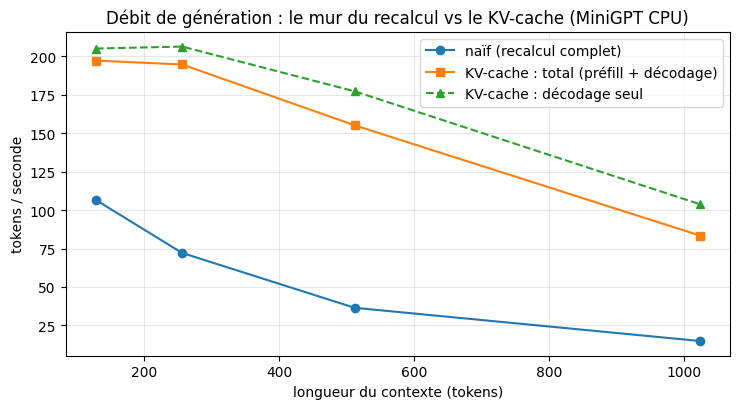

In [7]:
CTX_LENGTHS = [128, 256, 512, 1024]
N_NEW = 24

rows = []
for ctx_len in CTX_LENGTHS:
    torch.manual_seed(100 + ctx_len)
    prompt = torch.randint(0, CFG.vocab_size, (1, ctx_len))
    _, t_naive, _ = generate_naive(model, prompt, N_NEW)
    _, t_cached, per_step = generate_cached(model, prompt, N_NEW)
    tps_naive = N_NEW / t_naive
    tps_cached = N_NEW / t_cached                       # total : préfill + décodage
    t_decode = sum(per_step[1:])                        # décodage seul (préfill exclu)
    tps_decode = (N_NEW - 1) / t_decode
    rows.append((ctx_len, tps_naive, tps_cached, tps_decode))
    print(f"ctx={ctx_len:5d} | naïf {tps_naive:6.1f} tok/s"
          f" | cache total {tps_cached:6.1f} tok/s"
          f" | décodage seul {tps_decode:6.1f} tok/s"
          f" | speedup ×{tps_cached / tps_naive:.1f}")

print()
print(f"{'ctx':>6}{'tok/s naïf':>12}{'tok/s cache total':>19}{'tok/s décodage seul':>21}")
for r in rows:
    print(f"{r[0]:>6}{r[1]:>12.1f}{r[2]:>19.1f}{r[3]:>21.1f}")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
xs = [r[0] for r in rows]
ax.plot(xs, [r[1] for r in rows], "o-", label="naïf (recalcul complet)")
ax.plot(xs, [r[2] for r in rows], "s-", label="KV-cache : total (préfill + décodage)")
ax.plot(xs, [r[3] for r in rows], "^--", label="KV-cache : décodage seul")
ax.set_xlabel("longueur du contexte (tokens)")
ax.set_ylabel("tokens / seconde")
ax.set_title("Débit de génération : le mur du recalcul vs le KV-cache (MiniGPT CPU)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


**Lecture.** Trois régimes bien distincts :
- le débit naïf **s'effondre** quand le contexte croît : chaque pas paie un forward sur tout le préfixe, et ce préfixe grandit — coût total quadratique ;
- le débit caché **total** décroît doucement : il inclut le **préfill** (proportionnel au prompt), pesé de plus en plus lourd à génération courte ;
- le débit caché **en décodage seul** (préfill exclu) reste **stable** : chaque pas ne traite qu'un token, et consulter le cache (une concaténation et un produit ligne × cache) coûte peu — c'est la signature mécanique du cache.

Sur ce MiniGPT 4 couches en CPU, le speedup est modeste en valeur absolue — c'est la **forme** des courbes qui transporte la leçon : l'écart **croît avec le contexte**. Sur un vrai modèle (des dizaines de couches, des milliers de dimensions, GPU saturé), le même rapport devient le facteur qui décide si un service est utilisable ou pas. C'est ce que la partie 5 mesure sur notre vLLM.

## 4. Le prix du cache : la mémoire

Le cache n'est pas gratuit — il échange du calcul contre de la **mémoire vive**. Pour chaque couche, on conserve K **et** V pour chaque tête, chaque dimension de tête, chaque position :

`octets = n_couches × 2 (K,V) × n_têtes_kv × head_dim × seq_len × octets_par_élément`

Deux remarques de production :
- **GQA** (*grouped-query attention*) : les modèles récents gardent moins de têtes K/V que de têtes de requête (Llama-3.1-8B : 32 têtes Q, mais 8 têtes K/V) — le cache ne paie que les têtes KV.
- À **seq_len = 131 072** (contexte long), le cache peut dominer l'empreinte mémoire des poids eux-mêmes.


In [8]:
def cache_bytes_theoretical(n_layers, n_kv_heads, head_dim, seq_len, bytes_per_elem):
    """Octets du KV-cache complet pour une séquence de seq_len tokens."""
    return n_layers * 2 * n_kv_heads * head_dim * seq_len * bytes_per_elem


# --- configurations RÉELLES, chiffres publics des fiches modèles ---
configs = [
    # (nom, n_layers, n_kv_heads, head_dim, notes)
    ("GPT-2 small (MHA)",      12, 12,  64, "12 têtes K/V = 12 têtes Q"),
    ("Llama-3.1-8B (GQA)",     32,  8, 128, "32 têtes Q mais 8 têtes K/V seulement"),
    ("MiniGPT (ce notebook)",  CFG.n_layer, CFG.n_head, CFG.head_dim, "notre moteur d'étude"),
]

print(f"{'modèle':<26}{'fp16 @ 8k':>11}{'fp16 @ 32k':>12}{'fp16 @ 131k':>13}   remarque")
for name, L, H, hd, note in configs:
    b8 = cache_bytes_theoretical(L, H, hd, 8192, 2)
    b32 = cache_bytes_theoretical(L, H, hd, 32768, 2)
    b131 = cache_bytes_theoretical(L, H, hd, 131072, 2)
    print(f"{name:<26}{b8 / 1e9:>9.2f} GB{b32 / 1e9:>10.2f} GB{b131 / 1e9:>11.2f} GB   {note}")

# --- confrontation au MESURÉ sur notre MiniGPT : le cache réellement produit ---
torch.manual_seed(3)
probe = torch.randint(0, CFG.vocab_size, (1, 1024))
with torch.no_grad():
    _, caches = model(probe)
measured = sum((k.element_size() * k.nelement() + v.element_size() * v.nelement())
               for k, v in caches)
theoretical = cache_bytes_theoretical(CFG.n_layer, CFG.n_head, CFG.head_dim, 1024,
                                      caches[0][0].element_size())
print()
print(f"MiniGPT, seq=1024, dtype={caches[0][0].dtype} :")
print(f"  formule : {theoretical / 1e6:.2f} MB")
print(f"  mesuré  : {measured / 1e6:.2f} MB  (somme des tenseurs K/V réellement alloués)")
print(f"  écart   : {abs(measured - theoretical) / theoretical * 100:.4f} %")


modèle                      fp16 @ 8k  fp16 @ 32k  fp16 @ 131k   remarque
GPT-2 small (MHA)              0.30 GB      1.21 GB       4.83 GB   12 têtes K/V = 12 têtes Q
Llama-3.1-8B (GQA)             1.07 GB      4.29 GB      17.18 GB   32 têtes Q mais 8 têtes K/V seulement
MiniGPT (ce notebook)          0.02 GB      0.07 GB       0.27 GB   notre moteur d'étude



MiniGPT, seq=1024, dtype=torch.float32 :
  formule : 4.19 MB
  mesuré  : 4.19 MB  (somme des tenseurs K/V réellement alloués)
  écart   : 0.0000 %


**Lecture.** La formule colle au mesuré (l'écart est nul : le cache EST exactement ces tenseurs). La ligne Llama-3.1-8B montre l'enjeu : plus de 2 Go de cache rien que pour 131 072 tokens en fp16 — avant même de compter les poids. C'est ce coût qui motive les optimisations de service (PagedAttention de vLLM, quantification du cache, fenêtres glissantes).

---

### Exercice 1 — le cache d'un modèle inconnu

**Contexte.** On vous donne la fiche d'un modèle : 40 couches, 64 têtes de requête, **8 têtes K/V** (GQA), `head_dim = 128`, service en **bf16** (2 octets).

**Objectif.** Écrire `cache_bytes(n_layers, n_kv_heads, head_dim, seq_len, bytes_per_elem)` qui renvoie les octets du KV-cache — puis vérifier sur la fiche ci-dessus à `seq_len = 16 384`.

**Indices.** Ne pas confondre têtes Q et têtes K/V (c'est toute la différence GQA). Le facteur 2 compte K **et** V.


In [9]:
def cache_bytes(n_layers, n_kv_heads, head_dim, seq_len, bytes_per_elem):
    """Renvoie les octets du KV-cache complet.

    # Étape 1 : chaque couche conserve K et V -> facteur 2
    # Étape 2 : chaque tête K/V porte head_dim valeurs par position
    # Étape 3 : une position par token -> seq_len
    # Étape 4 : multiplier par la taille d'un élément (fp16/bf16 = 2 octets)
    """
    return None  # TODO étudiant


# --- auto-vérification (s'affiche seulement si l'exercice est complété) ---
result = cache_bytes(40, 8, 128, 16384, 2)
if result is None:
    print("Exercice 1 à compléter (cache_bytes renvoie None)")
else:
    attendu = 40 * 2 * 8 * 128 * 16384 * 2
    print(f"calculé : {result / 1e9:.2f} GB | attendu : {attendu / 1e9:.2f} GB | "
          f"{'OK' if result == attendu else 'ÉCART'}")


Exercice 1 à compléter (cache_bytes renvoie None)


## 5. Le pont vers la production : TTFT et ITL sur notre vLLM

La boucle est bouclée : les mécaniques ci-dessus sont **exactement** ce qu'un serveur d'inférence exécute pour chaque requête. Deux métriques de service en découlent directement :

- **TTFT** (*time-to-first-token*) : le temps du **préfill** — exécuter le prompt entier une fois (forward complet, comme notre premier pas naïf sur le prompt).
- **ITL** (*inter-token latency*) : le temps de chaque token suivant — un pas de **décodage incrémental avec KV-cache**.

La prédiction de la partie 1 devient une prédiction de service : **le TTFT croît avec la longueur du prompt** (préfill proportionnel au prompt), **l'ITL reste à peu près constante** (chaque pas décode 1 token contre le cache — indépendant de la longueur du prompt).

Mesurons-le sur **notre** vLLM self-hosted (qwen3.6-35b-a3b), en streaming : on chronomètre l'arrivée de chaque fragment SSE.


In [10]:
import requests as _rq

load_dotenv(dotenv_path="../.env")
VLLM_KEY = os.getenv("VLLM_API_KEY")
VLLM_BASE = os.getenv("VLLM_BASE_URL", "http://192.168.0.47:5002/v1")  # adresse LAN du vLLM du dépôt (cf 10_LocalLlama)


def vllm_alive():
    try:
        r = _rq.get(f"{VLLM_BASE}/models", headers={"Authorization": f"Bearer {VLLM_KEY}"},
                    timeout=8)
        if r.status_code == 200:
            return r.json()["data"][0]["id"]
        return None   # vivant mais clé refusée (401)
    except Exception:
        return None   # injoignable

MODEL_ID = vllm_alive()
if MODEL_ID is None:
    print("[RECOVERABLE-MACHINE] vLLM self-hosted injoignable ou clé refusée sur", VLLM_BASE)
    print("  -> la mesure RÉELLE exige la lane GenAI (po-2023) avec le vLLM du dépôt actif.")
    print("  -> AUCUNE valeur de substitution affichée (Stop & Repair, cf sota-not-workaround).")
else:
    print("vLLM joignable, modèle servi :", MODEL_ID)


vLLM joignable, modèle servi : qwen3.6-35b-a3b


In [11]:
FILLER = ("Le système d'information d'une assurance s'appuie sur des modèles de "
          "tarification qui segmentent le portefeuille par classes de risque observées. ")
QUESTION = "\n\nQuestion : résume ce texte en une seule phrase technique, sans liste."


def build_prompt(n_tokens_target):
    n_words = max(30, int(n_tokens_target / 1.45))   # ~1.45 mot/token en français
    reps = max(1, n_words // len(FILLER.split()))
    return FILLER * reps + QUESTION


def measure_ttft_itl(n_tokens_target, max_tokens=64):
    """Une requête STREAMING : renvoie (ttft_s, itl_moyenne_s, itl_mediane_s, n_fragments).

    On ne comptabilise que les fragments SSE qui PORTENT un jeton (delta non vide,
    contenu ou raisonnement) : les fragments de rôle/fin ne mesurent rien.
    TTFT = arrivée du premier jeton servi. ITL moyenne = (t_dernier - t_premier) /
    (n - 1), robuste aux salves réseau (plusieurs fragments arrivant dans le même
    paquet TCP, qui écraseraient une médiane d'intervalles vers 0)."""
    payload = {
        "model": MODEL_ID,
        "messages": [{"role": "user", "content": build_prompt(n_tokens_target)}],
        "max_tokens": max_tokens,
        "temperature": 0.0,
        "stream": True,
    }
    t_start = time.perf_counter()
    stamps = []
    with _rq.post(f"{VLLM_BASE}/chat/completions", json=payload, stream=True, timeout=180,
                  headers={"Authorization": f"Bearer {VLLM_KEY}"}) as r:
        r.raise_for_status()
        for line in r.iter_lines(decode_unicode=True):
            if not (line and line.startswith("data:")) or "[DONE]" in line:
                continue
            try:
                obj = json.loads(line[5:].strip())
            except Exception:
                continue
            delta = obj.get("choices", [{}])[0].get("delta", {})
            # ce vLLM emet le raisonnement sous delta.reasoning ; d'autres builds
            # OpenAI-compatibles utilisent delta.reasoning_content — on prend les deux
            if delta.get("content") or delta.get("reasoning") or delta.get("reasoning_content"):
                stamps.append(time.perf_counter() - t_start)
    ttft = stamps[0]
    itls = [b - a for a, b in zip(stamps, stamps[1:])]
    itl_mean = (stamps[-1] - stamps[0]) / (len(stamps) - 1)
    itl_med = sorted(itls)[len(itls) // 2] if itls else float("nan")
    return ttft, itl_mean, itl_med, len(stamps)


if MODEL_ID is not None:
    measure_ttft_itl(64)   # échauffement : première requête jetée (chemin froid)
    PROMPT_TOKENS = [250, 8000, 32000]
    N_REPEATS = 3
    vllm_rows = []
    for pt in PROMPT_TOKENS:
        runs = [measure_ttft_itl(pt) for _ in range(N_REPEATS)]
        ttfts = sorted(r[0] for r in runs)
        ttft_med = ttfts[N_REPEATS // 2]                       # médiane : robuste au bruit
        itl_mean = sum(r[1] for r in runs) / N_REPEATS
        vllm_rows.append((pt, ttft_med, itl_mean))
        print(f"prompt ~{pt:5d} tok | TTFT médiane {ttft_med:6.2f} s "
              f"(min {ttfts[0]:.2f} / max {ttfts[-1]:.2f}, {N_REPEATS} requêtes) "
              f"| ITL moyenne {itl_mean * 1000:5.1f} ms")

    print()
    print("Mesures RÉELLES en streaming sur le vLLM self-hosted du dépôt.")
    print("TTFT = premier jeton servi (médiane de 3 requêtes) ; ITL = cadence")
    print("inter-jetons moyenne (robuste aux salves réseau).")
else:
    vllm_rows = []
    print("(passe : service injoignable, verdict [RECOVERABLE-MACHINE] affiché plus haut)")


prompt ~  250 tok | TTFT médiane   0.09 s (min 0.08 / max 0.09, 3 requêtes) | ITL moyenne   8.0 ms


prompt ~ 8000 tok | TTFT médiane   0.28 s (min 0.27 / max 0.28, 3 requêtes) | ITL moyenne   8.8 ms


prompt ~32000 tok | TTFT médiane   0.37 s (min 0.36 / max 2.61, 3 requêtes) | ITL moyenne  11.6 ms

Mesures RÉELLES en streaming sur le vLLM self-hosted du dépôt.
TTFT = premier jeton servi (médiane de 3 requêtes) ; ITL = cadence
inter-jetons moyenne (robuste aux salves réseau).


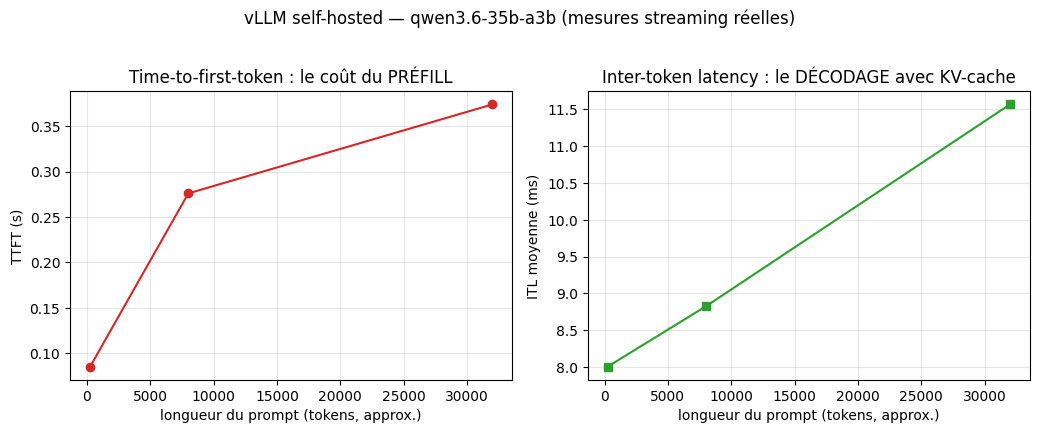

In [12]:
if vllm_rows:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))
    xs = [r[0] for r in vllm_rows]
    ax1.plot(xs, [r[1] for r in vllm_rows], "o-", color="tab:red")
    ax1.set_xlabel("longueur du prompt (tokens, approx.)")
    ax1.set_ylabel("TTFT (s)")
    ax1.set_title("Time-to-first-token : le coût du PRÉFILL")
    ax1.grid(alpha=0.3)

    ax2.plot(xs, [r[2] * 1000 for r in vllm_rows], "s-", color="tab:green")
    ax2.set_xlabel("longueur du prompt (tokens, approx.)")
    ax2.set_ylabel("ITL moyenne (ms)")
    ax2.set_title("Inter-token latency : le DÉCODAGE avec KV-cache")
    ax2.grid(alpha=0.3)
    fig.suptitle(f"vLLM self-hosted — {MODEL_ID} (mesures streaming réelles)", y=1.02)
    fig.tight_layout()
    plt.show()


**Lecture — le pont.** À gauche, le TTFT grimpe quand le prompt s'allonge : c'est le **préfill**, la même montée du mur que notre courbe naïf×contexte de la partie 3. À droite, l'ITL reste **à peu près constante** : chaque jeton supplémentaire ne paie qu'un pas de décodage incrémental contre le cache — indépendant de la longueur du prompt, exactement la branche « décodage seul » de notre courbe de débit. Quand vous lirez les métriques d'un serveur vLLM en charge, vous saurez désormais **quoi** elles mesurent : un TTFT qui dérive attaque la capacité de préfill ; une ITL qui dérive attaque le décodage (ou la mémoire du cache).

## 6. Ouverture : le décodage spéculatif, en cinq lignes

Un petit modèle *draft* propose k tokens à la suite (rapides) ; le gros modèle les **vérifie en un seul forward** sur les k positions à la fois (le préfill sait traiter plusieurs positions d'un coup, le décodage incrémental non) ; on accepte le plus long préfixe que le gros modèle confirme, on rejette le reste et on repart de là. Espoir : payer k pas de décodage au prix d'un forward groupé — rentable tant que le petit modèle devine assez bien.

---

### Exercice 2 — tronquer le cache (fenêtre glissante)

**Contexte.** Un service doit borner la mémoire : on ne garde que les `max_len` **dernières** positions du cache (fenêtre glissante). Le modèle continue de générer contre cette fenêtre.

**Objectif.** Écrire `trim_cache(caches, max_len)` qui renvoie un nouveau cache où chaque tenseur K/V ne conserve que les dernières `max_len` positions (dimension 2 : `(B, nh, T, hd)`).

**Indices.** Le cache est une liste de tuples `(k, v)` par couche. Le slicing torch sur la dimension 2 fait l'affaire ; ne pas modifier les tenseurs en place (le cache est partagé entre les pas).


In [13]:
def trim_cache(caches, max_len):
    """Renvoie un nouveau cache ne gardant que les max_len dernières positions.

    caches : liste de tuples (k, v) par couche, chacun (B, n_head, T, head_dim).
    # Indice : k[:, :, -max_len:, :] garde les max_len dernières positions.
    """
    return None  # TODO étudiant


# --- auto-vérification ---
torch.manual_seed(5)
_, demo_caches = model(torch.randint(0, CFG.vocab_size, (1, 300)))
trimmed = trim_cache(demo_caches, 128)
if trimmed is None:
    print("Exercice 2 à compléter (trim_cache renvoie None)")
else:
    ok_shapes = all(k.shape[2] == 128 and v.shape[2] == 128 for k, v in trimmed)
    ok_contenu = torch.equal(trimmed[0][0], demo_caches[0][0][:, :, -128:, :])
    print(f"formes : {'OK' if ok_shapes else 'KO'} | contenu = dernières positions : "
          f"{'OK' if ok_contenu else 'KO'}")


Exercice 2 à compléter (trim_cache renvoie None)


---

### Exercice 3 — accepter ou rejeter (le cœur du spéculatif)

**Contexte.** Le petit modèle a proposé les tokens `[t1, t2, t3]`. Le gros modèle, consulté en un seul forward groupé, produit les logits `L1, L2, L3` pour ces trois positions. Règle d'acceptation gloutonne : on accepte `t1` si `argmax(L1) == t1` ; puis `t2` si `argmax(L2) == t2` ; etc. Au premier désaccord on s'arrête (le token correct est déjà connu : l'argmax du désaccord).

**Objectif.** Écrire `accepted_prefix(draft_tokens, logits_per_pos)` qui renvoie le nombre de tokens acceptés avant le premier rejet.

**Indices.** `torch.equal` sur des tenseurs 0-d fait l'affaire ; une boucle avec `break` est parfaitement lisible ici.


In [14]:
def accepted_prefix(draft_tokens, logits_per_pos):
    """Nombre de tokens du draft acceptés avant le premier désaccord glouton.

    draft_tokens   : LongTensor (k) — la proposition du petit modèle
    logits_per_pos : FloatTensor (k, vocab) — les logits du gros modèle
    # Étape 1 : pour chaque position, l'argmax du gros modèle est sa confirmation
    # Étape 2 : accepter tant que les deux coïncident, s'arrêter au premier écart
    """
    return None  # TODO étudiant


# --- auto-vérification ---
draft = torch.tensor([17, 4, 92, 55])
logits = torch.zeros(4, CFG.vocab_size)
logits[0, 17] = 5.0   # confirme t1
logits[1, 4] = 5.0    # confirme t2
logits[2, 31] = 5.0   # REFUTE t3 (le gros modèle veut 31, pas 92)
logits[3, 55] = 5.0   # (jamais atteint)
res = accepted_prefix(draft, logits)
if res is None:
    print("Exercice 3 à compléter (accepted_prefix renvoie None)")
else:
    print(f"attendu : 2 (t1, t2 acceptés ; t3 refusé) | obtenu : {res} "
          f"-> {'OK' if res == 2 else 'ÉCART'}")


Exercice 3 à compléter (accepted_prefix renvoie None)


## Conclusion

| Notion | Ce notebook l'a montré par |
|---|---|
| Le mur du recalcul | débit naïf qui s'effondre à contexte croissant (partie 3, courbe) |
| Le KV-cache | implémenté à la main, porté par l'appelant, pas à pas (partie 1) |
| Son exactitude | logits naïfs vs cachés : écart d'epsilon float32, argmax identiques (partie 2) |
| Son coût mémoire | formule confrontée au mesuré — écart nul ; GQA divise la facture (partie 4) |
| Le lien au service | TTFT (préfill) qui croît, ITL (décodage + cache) qui reste plate — mesuré sur notre vLLM (partie 5) |

**Ce qu'on retient pour la production** : lire `TTFT` et `ITL` dans les métriques d'un serveur, c'est relire la partie 3 de ce notebook en production. Un vLLM qui tient son débit est un serveur dont le cache est bien géré (PagedAttention) — et le jour où l'ITL dérive, la première question est celle de la partie 4 : combien de mémoire reste-t-il pour le cache ?

**Pour aller plus loin** : [10_LocalLlama](10_LocalLlama.ipynb) (le déploiement), [11_Quantization](11_Quantization.ipynb) (compresser les poids — le cache, lui, se gère autrement), [22_Evaluating_Generated_Text](22_Evaluating_Generated_Text.ipynb) (évaluer ce que génère le service).
